# Stratified Sampling


Compare sampling approaches in terms of spatial and temporal variation in model performance.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

from itertools import chain
from tqdm import tqdm
from collections import defaultdict
from IPython.display import clear_output
from sampling import UncertaintyQuantification

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


### DATA SAMPLING

In [2]:
# ============================================
# DATASET SELECTION - Choose your dataset here
# ============================================

# Option 1: Load dataset
DATASET = "wabad"  # Options: "anuraset" or "wabad"

# ============================================
# Load data using the adapter
# ============================================
from adapter import loader
from torch.utils.data import TensorDataset, DataLoader

# Load training data
tensor_x_train, tensor_y_train, train_filenames = loader(DATASET, sub_directory="train")

# Load test data
tensor_x_test, tensor_y_test, test_filenames = loader(DATASET, sub_directory="test")

# Optional: Load validation data (if available)
# For WABAD:
if DATASET == "wabad":
    tensor_x_val, tensor_y_val, val_filenames = loader(DATASET, sub_directory="validation")
    val_dataset = TensorDataset(tensor_x_val, tensor_y_val)
    batch_size = 20
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
else:
    # For AnuraSet, use test set as validation
    val_dataset = TensorDataset(tensor_x_test, tensor_y_test)
    batch_size = 20
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

print(f"Dataset: {DATASET}")
print(f"Training set shape: {tensor_x_train.shape}, {tensor_y_train.shape}")
print(f"Test set shape: {tensor_x_test.shape}, {tensor_y_test.shape}")

Dataset: wabad
Training set shape: torch.Size([13453, 1024]), torch.Size([13453, 106])
Test set shape: torch.Size([16123, 1024]), torch.Size([16123, 106])


Model

In [3]:
import torch.nn as nn

class ClassificationHead(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=256, weight_matrix=None, bias_vector=None):
        super(ClassificationHead, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        
        if weight_matrix is not None:
            with torch.no_grad():  # Disable gradient tracking during initialization
                self.fc.weight = nn.Parameter(torch.tensor(weight_matrix, dtype=torch.float32))
        
        if bias_vector is not None:
            with torch.no_grad():  # Disable gradient tracking during initialization
                self.fc.bias = nn.Parameter(torch.tensor(bias_vector, dtype=torch.float32))

    def forward(self, x):
        x = self.hidden(x)
        x = self.fc(x)
        return x


# Evaluation Across Strata

In [4]:
def binaryEntropy(outputs: torch.Tensor, eps=1e-8) -> torch.Tensor:
    entropy = -(outputs * torch.log2(outputs + eps) + (1 - outputs) * torch.log2(1 - outputs + eps))  # (B, C)
    entropy = torch.nan_to_num(entropy)
    return entropy

def predictions(embeddings: torch.Tensor, labels: torch.Tensor, model=None):
    model.eval()
    with torch.no_grad():
        outputs = model(embeddings)
        y_pred = torch.sigmoid(outputs)
    uncertainty = binaryEntropy(y_pred)
    return y_pred, labels, uncertainty


In [5]:
# Measuring Evenness between strata

def pielou_evenness(values):
    values = np.array(values)
    if np.any(values < 0):
        raise ValueError("Values must be non-negative")
    total = values.sum()
    if total == 0:
        return 0.0  # undefined if all values are zero
    probs = values / total
    entropy = -np.sum(probs * np.log(probs + 1e-10))  # add epsilon for safety
    max_entropy = np.log(len(values))
    return entropy / max_entropy

def coefficient_of_variation(values):
    return np.std(values) / np.mean(values)


## Per location evaluation

In [6]:
def stratified_evaluation(stratified_indices: dict, y_pred: torch.Tensor, y_true: torch.Tensor, uncertainty: torch.Tensor, indices_selected:dict=None, metric='mAP', init_mAP=None, init_mAE=None, plot=False):
    """
    Evaluate model performance (mAP) and uncertainty (binary entropy) per species and strata
    Parameters:
        stratified_indices: dict of list of indices for each strata
    """
    strata_mAP = []
    strata_mAE = []

    # Evaluate mAP per location
    for loc, indices in stratified_indices.items():
        y_true_strata = y_true[indices]
        y_pred_strata = y_pred[indices]

        valid_classes = y_true_strata.sum(axis=0) > 0

        y_true_strata = y_true_strata[:, valid_classes]
        y_pred_strata = y_pred_strata[:, valid_classes]
        preds = (y_pred_strata > 0.5).float()

        # Compute entropy per class and location
        valid_entropy = uncertainty[indices][:, valid_classes]
        per_class_entropy = valid_entropy.mean(axis=0)
        mAE = per_class_entropy.mean()
        
        if metric == 'mAP':
            score = average_precision_score(y_true_strata, y_pred_strata, average='weighted')
        elif metric == 'cmAP':
            score = average_precision_score(y_true_strata, y_pred_strata, average="macro", sample_weight=None)
        elif metric == 'F1_macro':
            score = f1_score(y_true_strata, preds, average="macro")
        else:
            raise Exception("Evaluation metric doesn't exist, pick from (mAP, cmAP, F1_macro)")

        strata_mAP.append(score)
        strata_mAE.append(mAE.item())

    if plot:
        print(f"Pielou Evenness: {pielou_evenness(strata_mAP):.3f}")
        print(f"Coefficient of Variation: {coefficient_of_variation(strata_mAP):.3f}")

        strata = list(stratified_indices.keys())
        fig, ax = plt.subplots(1, 2, figsize=(6 , 6), gridspec_kw={'width_ratios': [2, 3]}, sharey=True)

        if init_mAP is not None:
            strata_mAP = np.subtract(strata_mAP, init_mAP).tolist()
            ax[0].set_xlabel(f'Relative {metric}', fontsize=12)
        else:
            ax[0].set_xlabel(f'{metric}', fontsize=12)

        ax[0].barh(strata[::-1], strata_mAP[::-1])
        # ax[0].barh(strata[::-1], strata_mAE[::-1], alpha=0.5)

        if indices_selected is not None:
            selected = []
            indices_selected = {k: indices_selected[k] for k in stratified_indices} # Aligns train/test dicts due to differring samples counts
            keys = list(indices_selected.keys())
            for strata_indices in indices_selected.values():
                selected.append(len(strata_indices))
            ax[1].barh(keys[::-1], selected[::-1])
            ax[1].set_xlabel('Number of Samples selected', fontsize=12) 
        else:
            keys = list(stratified_indices.keys())
            counts = [len(v) for v in stratified_indices.values()]
            ax[1].barh(keys[::-1], counts[::-1])
            ax[1].set_xlabel('Total Samples', fontsize=12) 

        ax[0].set_ylabel(f'Strata', fontsize=12)
        ax[0].set_xlim(-0.5,1)
        ax[0].tick_params(axis='both', which='major', labelsize=10)
        plt.grid(True, axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return strata_mAP, strata_mAE

def stratified_evaluation_with_variance(stratified_indices: dict, y_pred: torch.Tensor, y_true: torch.Tensor, indices_selected:dict=None, metric='mAP', init_mAP=None, init_mAE=None, plot=False, strata_mode=None):
    """
    Evaluate model performance (mAP) and uncertainty (binary entropy) per species and strata
    Parameters:
        stratified_indices: dict of list of indices for each strata
    """
    all_results = []

    for index in range(y_pred.shape[0]):
        strata_mAP = []
        # Evaluate mAP per location
        for loc, indices in stratified_indices.items():
            y_true_strata = y_true[index][indices]
            y_pred_strata = y_pred[index][indices]

            valid_classes = y_true_strata.sum(axis=0) > 0

            y_true_strata = y_true_strata[:, valid_classes]
            y_pred_strata = y_pred_strata[:, valid_classes]
            preds = (y_pred_strata > 0.5).float()
            
            if metric == 'mAP':
                score = average_precision_score(y_true_strata, y_pred_strata, average='weighted')
            elif metric == 'cmAP':
                score = average_precision_score(y_true_strata, y_pred_strata, average="macro", sample_weight=None)
            elif metric == 'F1 (macro)':
                score = f1_score(y_true_strata, preds, average="macro")
            else:
                raise Exception("Evaluation metric doesn't exist, pick from (mAP, cmAP, F1_macro)")
            strata_mAP.append(score)

        all_results.append(strata_mAP)

    all_results = torch.Tensor(all_results)
    strata_mean = torch.mean(all_results, dim=0).tolist()
    strata_var = torch.std(all_results, dim=0).tolist()

    if plot:
        print(f"Pielou Evenness: {pielou_evenness(strata_mean):.3f}")
        print(f"Coefficient of Variation: {coefficient_of_variation(strata_mean):.3f}")

        strata = list(stratified_indices.keys())
        
        fig, ax = plt.subplots(1, 2, figsize=(6 , 6), gridspec_kw={'width_ratios': [2, 3]}, sharey=True)

        if init_mAP is not None:
            print(init_mAP)
            print(strata_mean)
            strata_mean = np.subtract(strata_mean, init_mAP).tolist()
            print(strata_mean)

            ax[0].set_xlabel(f'Relative {metric}', fontsize=12)
        else:
            ax[0].set_xlabel(f'{metric}', fontsize=12)

        ax[0].barh(strata[::-1], strata_mean[::-1], xerr=strata_var[::-1], alpha=0.5, capsize=5, ecolor="dimgrey")
        ax[0].axvline(0.0, color='gray', linewidth=1)
        ax[0].axvline(np.mean(strata_mean), alpha=0.5, linestyle='--', linewidth=2)

        if indices_selected is not None:
            selected = []
            indices_selected = {k: indices_selected[k] for k in stratified_indices} # Aligns train/test dicts due to differring samples counts
            keys = list(indices_selected.keys())
            for strata_indices in indices_selected.values():
                selected.append(len(strata_indices))
            ax[1].barh(keys[::-1], selected[::-1])
            ax[1].set_xlabel('Number of Samples selected', fontsize=12) 
        else:
            keys = list(stratified_indices.keys())
            counts = [len(v) for v in stratified_indices.values()]
            ax[1].barh(keys[::-1], counts[::-1])
            ax[1].set_xlabel('Total Samples', fontsize=12) 

        ax[0].set_ylabel(f'Strata ({strata_mode})', fontsize=12)
        ax[0].set_xlim(-0.1,1.0)
        ax[0].tick_params(axis='both', which='major', labelsize=10)
        plt.grid(True, axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return strata_mAP

def temporal_split(files, res=4):
    year_code = [loc.split('_')[1][:res] for loc in files]
    value_to_indices = defaultdict(list)

    for idx, val in enumerate(year_code):
        value_to_indices[val].append(idx)
    value_to_indices = dict(value_to_indices)

    sorted_dict = dict(sorted(value_to_indices.items(), key=lambda x: int(x[0])))
    sorted_time_to_indices = dict(sorted_dict)
    return sorted_time_to_indices

def temporal_custom(files, res=6):
    year_code = [loc.split('_')[1][:res] for loc in files]
    value_to_indices = defaultdict(list)

    custom = {"A": ['201909', '201910', '201911'], "B":['201912', '202001', '202002', '202003', '202004'], "C":['202010', '202011', '202012', '202101']}

    for idx, val in enumerate(year_code):
        for custom_key, dates in custom.items():
            if val in dates:
                value_to_indices[custom_key].append(idx)
    value_to_indices = dict(value_to_indices)

    return value_to_indices


def spatial_split(files):
    # Collect indices per location
    location_codes = [loc.split('_')[0] for loc in files]
    value_to_indices = defaultdict(list)

    for idx, val in enumerate(location_codes):
        value_to_indices[val].append(idx)
    value_to_indices = dict(value_to_indices)

    sorted_locs = sorted(value_to_indices.items(), key=lambda item: len(item[1]), reverse=True)
    sorted_location_to_indices = dict(sorted_locs)
    return sorted_location_to_indices


# Evaluation Across Strata

In [7]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy as kl
import seaborn as sns


def correlation(sorted_indices, probabilities=None, uncertainty=None, embeddings=None, labels=None, mode='prob', plot=True):                     
    if mode == 'prob':
        sorted_scores = {key: probabilities[idx] for key, idx in sorted_indices.items()}
    elif mode == 'entropy':
        sorted_scores = {key: uncertainty[idx] for key, idx in sorted_indices.items()}
    elif mode == 'embedding':
        sorted_scores = {key: embeddings[idx] for key, idx in sorted_indices.items()}
    elif mode == 'labels':
        sorted_scores = {key: tensor_y_test[idx].float()/torch.sum(tensor_y_test[idx]) for key, idx in sorted_indices.items()}

    def js_divergence(pA, pB):
        return jensenshannon(pA.mean(axis=0), pB.mean(axis=0)) ** 2
    
    def kl_divergence(pA, pB):
        return kl(pA.mean(axis=0), pB.mean(axis=0))
    
    def cosine_sim(A, B, max_samples=10000):
        A = A[np.random.choice(A.shape[0], int(min(max_samples, A.shape[0])), replace=False)]
        B = B[np.random.choice(B.shape[0], int(min(max_samples, B.shape[0])), replace=False)]

        A = F.normalize(A)
        B = F.normalize(B)
        similarity = A @ B.T
        return similarity.mean()

    location_names = list(sorted_scores.keys())
    n = len(location_names)
    js_matrix = np.zeros((n, n))

    for i in range(n):
        loc1 = location_names[i]
        for j in range(n):
            loc2 = location_names[j]

            if mode == "embeddings":
                js_matrix[i,j] = cosine_sim(sorted_scores[loc1], sorted_scores[loc2])
            else:
                js_matrix[i,j] = js_divergence(sorted_scores[loc1], sorted_scores[loc2])

    if plot:
        sns.clustermap(js_matrix, 
                    row_cluster=False, col_cluster=False, 
                    figsize=(8, 8), 
                    xticklabels=location_names, yticklabels=location_names, 
                    cmap="magma", linewidths=0.5)
        plt.suptitle("Clustered JS Divergence Between Locations", y=1.02)
        plt.show()
    return js_matrix


In [8]:
# --- Model Hyperparameters ---
import torch.nn as nn
import torch.optim as optim

learning_rate = 0.01
num_epochs = 20

lambda_reg_weights = 0.0005
lambda_reg_bias = 0.0005
initialisation = False

input_dim = tensor_x_train.shape[1]
num_classes =  tensor_y_train.shape[1]
# ---

# Initialize birdnet_weights and birdnet_bias as None if not using pretrained weights
if initialisation:
    # NOTE: If you want to use BirdNet initialization, uncomment cell 12 first
    # Then uncomment the following lines:
    # model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=birdnet_weights.clone().detach(), bias_vector=birdnet_bias.clone().detach()).to(device)
    raise NotImplementedError("BirdNet initialization is currently disabled. Uncomment cell 12 first to enable it.")
else:
    model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=None, bias_vector=None).to(device)

criterion = nn.BCEWithLogitsLoss()
strata_criterion = nn.BCEWithLogitsLoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, min_lr=0.001)


In [9]:
def stratified_regularisation(outputs, labels, batched_idx, sorted_indices, lambda_reg=0.1, eps=1e-4, mode="mad"):
    strata_indices = {}
    for key, value in sorted_indices.items():
        strata_indices[key] = np.intersect1d(value, batched_idx)

    strata_loss = []
    for key, value in strata_indices.items():
        strata_filter = ([i for i, idx in enumerate(batched_idx) if idx.item() in value])
        if len(strata_filter) > 0:
            strata_outputs = outputs[strata_filter]
            strata_labels = labels[strata_filter]
            loss = criterion(strata_outputs.float(), strata_labels.float())
            strata_loss.append(loss)
            
    stratum_losses = torch.stack(strata_loss)

    if mode == "var":
        loss = torch.mean((stratum_losses - stratum_losses.mean()) ** 2)
    elif mode == "mad":
        loss = torch.mean(torch.abs(stratum_losses - stratum_losses.mean()))
    elif mode == "cv":
        loss = stratum_losses.std(unbiased=False) / (stratum_losses.mean() + eps)
    elif mode == "harmonic":
        harmonic_mean = len(stratum_losses) / torch.sum(1.0 / (stratum_losses + eps)) # Unstable
        loss = stratum_losses.std(unbiased=False) / (harmonic_mean + eps)
    elif mode == "minmax":
        loss = stratum_losses.max() - stratum_losses.min()
    elif mode == "max":
        loss = stratum_losses.max()
    return lambda_reg * loss


In [10]:
sorted_indices_train = temporal_custom(train_filenames)

In [11]:
# --- Active Learning Hyperparameters --- 
n_samples = 54
initial_samples = 20
accumulation = True

initial_sampling_mode = "stratified"
sampling_mode = "stratified"
sub_sampling_mode = "binary"
strata_mode = "spatial"

posthoc_sampling = True
posthoc_target = 20

alpha = 2
# ---

y_pred, y_true, uncertainty = predictions(tensor_x_train, tensor_y_train, model=model)

if strata_mode == "spatial":
    sorted_indices_train = spatial_split(train_filenames)
elif strata_mode == "temporal":
    sorted_indices_train = temporal_split(train_filenames)
elif strata_mode == "custom":
    sorted_indices_train = temporal_custom(train_filenames)

strata_mAP, strata_mAE = stratified_evaluation(sorted_indices_train, y_pred, y_true, uncertainty, plot=False)

# Stratafied sampling
sampling = UncertaintyQuantification(tensor_x_train, tensor_y_train, n_samples)

if initial_sampling_mode == "stratified":
    strata_idx = sampling.stratified(model, sorted_indices_train, method=sub_sampling_mode, weights=None)

    # location = "INCT20955"
    # idx = strata_idx[location]
    # embeddings = tensor_x_train[idx]
    # labels = tensor_y_train[idx]

    # strata_idx = {k: [] for k in strata_idx}
    # strata_idx[location] = idx

    idx = list(chain.from_iterable(strata_idx.values()))
else:
    idx = sampling.resample(model, method=initial_sampling_mode, override=initial_samples) # initial sampling fixed at 20 samples

indices = list(idx)

embeddings = tensor_x_train[idx]
labels = tensor_y_train[idx]

train_loader = DataLoader(TensorDataset(embeddings, labels, torch.tensor(indices)), batch_size=batch_size, shuffle=True)

y_pred_test, y_true_test, uncertainty, = predictions(tensor_x_test, tensor_y_test, model=model) # Recompute predictions/uncertanty using updated model


similarity_matrix = correlation(sorted_indices_train, probabilities=y_pred, plot=False)
weights = similarity_matrix.sum(axis=1) ** alpha
weights = torch.tensor(weights / weights.sum())

if strata_mode == "spatial":
    sorted_indices = spatial_split(test_filenames)
elif strata_mode == "temporal":
    sorted_indices = temporal_split(test_filenames)
elif strata_mode == "custom":
    sorted_indices = temporal_custom(test_filenames)
    
strata_mAP, strata_mAE = stratified_evaluation(sorted_indices, y_pred_test, y_true_test, uncertainty, indices_selected=None, metric="F1_macro", plot=False)
initial_results = {"strata": list(sorted_indices_train.keys()),
                   "mAP": strata_mAP,
                   "mAE": strata_mAE}

initial_results_df = pd.DataFrame(initial_results)

In [12]:
sorted_indices_res = temporal_split(train_filenames, res=8)

In [13]:

matrix = correlation(sorted_indices, embeddings=tensor_x_test, mode="embedding", plot=False)

In [14]:

max_repeatitions = 1
predictions_list = []
labels_list = []

for reps in range(max_repeatitions):
    all_selected = []
    strata_selected = {}
    BCE_loss = []
    strat_loss = []
    
    F1_TE = []
    total_samples = []

    if reps > 0:
        print(f"Resetting model")
        if initialisation:
            # NOTE: BirdNet initialization is disabled - uncomment cell 12 to enable
            raise NotImplementedError("BirdNet initialization is currently disabled. Uncomment cell 12 first to enable it.")
        else:
            model = ClassificationHead(input_size=input_dim, output_size=num_classes, weight_matrix=None, bias_vector=None).to(device)

    criterion = nn.BCEWithLogitsLoss()
    strata_criterion = nn.BCEWithLogitsLoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, min_lr=0.001)

    for epoch in tqdm(range(num_epochs), disable=True):
        for i, (inputs, labels, batched_idx) in enumerate(train_loader):
            model.train()
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs.float(), labels.float())
            
            if initialisation:
                # NOTE: BirdNet initialization is disabled
                raise NotImplementedError("BirdNet initialization is currently disabled. Uncomment cell 12 first to enable it.")
            else:
                # lambda_weight = epoch
                stratified_loss = stratified_regularisation(outputs, labels, batched_idx, sorted_indices_train, mode="max", lambda_reg=1)
                total_loss = loss #+ stratified_loss

                BCE_loss.append(loss.detach().cpu().numpy())    
                strat_loss.append(stratified_loss.detach().cpu().numpy())

            total_loss.backward()
            optimizer.step()

        # --- Eval ---
        y_pred_test, _, uncertainty, = predictions(tensor_x_test, tensor_y_test, model=model)

        valid_classes = tensor_y_test.sum(axis=0) > 0
        label = tensor_y_test[:, valid_classes]
        probs = y_pred_test[:, valid_classes]
        preds = (probs > 0.5).float()

        mAP = average_precision_score(label, probs, average="weighted", sample_weight=None)
        cmAP = average_precision_score(label, probs, average="macro", sample_weight=None)
        F1_macro = f1_score(label, preds, average="macro")
        
        scheduler.step(mAP)
        print(f"Runs {reps+1} | Epoch {epoch+1}: mAP: {mAP:.4f}, cmAP: {cmAP:.4f} | F1 Macro: {F1_macro:.4f} | {scheduler.get_last_lr()[0]}")

        # --- Resampling ---
        if sampling_mode == "stratified":
            if epoch < 10:
                weights = None
            strata_idx = sampling.stratified(model, sorted_indices_train, method=sub_sampling_mode, indices=all_selected, weights=None)

            # # Filter by strata
            # strata = "INCT20955"
            # idx = strata_idx[strata]
            # embeddings = tensor_x_train[idx]
            # labels = tensor_y_train[idx]

            # strata_idx = {k: [] for k in strata_idx}
            # strata_idx[strata] = idx

            idx = list(chain.from_iterable(strata_idx.values()))

            if posthoc_sampling and (len(idx) > posthoc_target):
                idx = np.random.choice(idx, size=posthoc_target, replace=False)
        else:
            idx = sampling.resample(model, method=sampling_mode, indices=all_selected)

        if accumulation:
            indices += list(idx)
        else:
            indices = idx
        all_selected += list(idx)

        train_loader = DataLoader(TensorDataset(tensor_x_train[all_selected], tensor_y_train[all_selected], torch.tensor(all_selected)), batch_size=batch_size, shuffle=True)

        similarity_matrix = correlation(sorted_indices, probabilities=y_pred_test, plot=False)
        weights = similarity_matrix.sum(axis=1) ** alpha
        weights = torch.tensor(weights / weights.sum())

        # --- Evaluate on test set across strata ---
        for key, value in sorted_indices_train.items():
            strata_selected[key] = np.intersect1d(value, all_selected)
        strata_idx = strata_selected

        if strata_mode == "spatial":
            sorted_indices = spatial_split(test_filenames)
        elif strata_mode == "temporal":
            sorted_indices = temporal_split(test_filenames)

        # print(strata_idx)
        strata_mAP, strata_mAE = stratified_evaluation(sorted_indices, y_pred_test, tensor_y_test, uncertainty, indices_selected=strata_idx, init_mAP=None, metric="F1_macro", plot=False) # init_mAP=initial_results_df["mAP"]
        # total_samples.append(len(all_selected))
        # F1_TE.append(np.mean(strata_mAP))
        # plt.plot(total_samples, F1_TE)
        # plt.show()

        clear_output(wait=True)

    predictions_list.append(y_pred_test)
    labels_list.append(tensor_y_test)

all_predictions = torch.stack(predictions_list, dim=0)
all_labels = torch.stack(labels_list, dim=0)



Runs 1 | Epoch 20: mAP: 0.4469, cmAP: 0.1632 | F1 Macro: 0.1119 | 0.01


C:\Users\bjmcewen\AppData\Local\Temp\ipykernel_33244\3420614224.py:112: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ..\aten\src\ATen\native\ReduceOps.cpp:1760.)
  strata_var = torch.std(all_results, dim=0).tolist()


Pielou Evenness: 0.979
Coefficient of Variation: 0.372


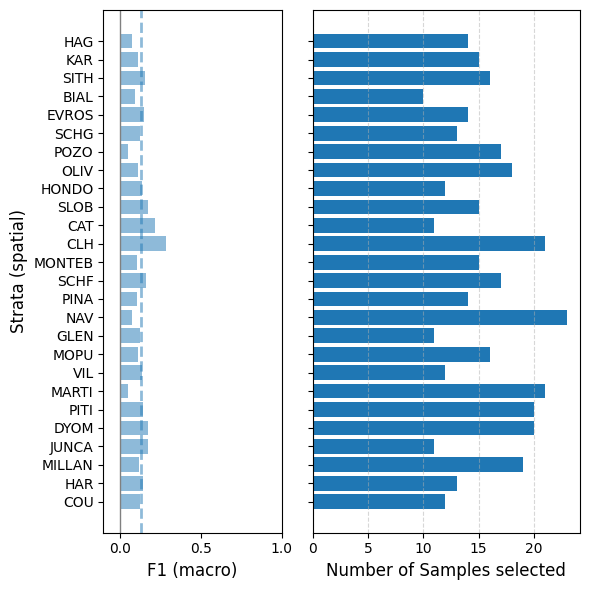

[0.07598002020428152,
 0.11560632472759816,
 0.1555800460199346,
 0.09390653575406077,
 0.15333176213977626,
 0.12486147369075681,
 0.04945264522373941,
 0.11413275733927909,
 0.1387499244844465,
 0.177041998138044,
 0.21999929606500337,
 0.28626264240310306,
 0.10540224719101124,
 0.163382759201868,
 0.10479462596524232,
 0.07848592579422238,
 0.1235565281819779,
 0.11169001062401163,
 0.1357486082827686,
 0.05027322404371584,
 0.14559640360133916,
 0.1758132920232623,
 0.1779025419627127,
 0.11700680272108843,
 0.14533963311137224,
 0.12525254818278814]

In [15]:
stratified_evaluation_with_variance(sorted_indices, all_predictions, all_labels, indices_selected=strata_idx, init_mAP=None, metric="F1 (macro)", plot=True, strata_mode=strata_mode)

In [16]:

def mutual_information(sorted_indices, y):

    def entropy(p, eps=1e-10):
        return -torch.sum((p + eps) * torch.log2(p + eps))

    sorted_scores = {key: y[idx] for key, idx in sorted_indices.items()}

    # Convert to categorical distribution over classes
    y_cat = []
    y_weight = []
    total = len(list(chain.from_iterable(sorted_scores.values())))
    for i, (strata, probs) in enumerate(sorted_scores.items()):
        weight = probs.shape[0] / total
        probs = torch.sum(probs, dim=0) / torch.sum(probs)
        y_cat.append(probs)
        y_weight.append(weight)

    P_y = sum(y_weight[k] * y_cat[k] for k in range(len(y_cat)))

    H_y = entropy(P_y)

    H_y_given_s = sum(
        y_weight[k] * entropy(y_cat[k])
        for k in range(len(y_cat))
    )

    I_sy = H_y - H_y_given_s
    print(f"Mutual Information I(S;Y): {I_sy:.4f}")
    print(I_sy/H_y)

# For label distribution: tensor_y_test
# For predictive distribution: y_pred_test
mutual_information(sorted_indices, y_pred_test)

Mutual Information I(S;Y): 1.3287
tensor(0.3222)


## Predictive Distribution

Pairwise JS-divergence between the distribution of predictive probabilities within strata.

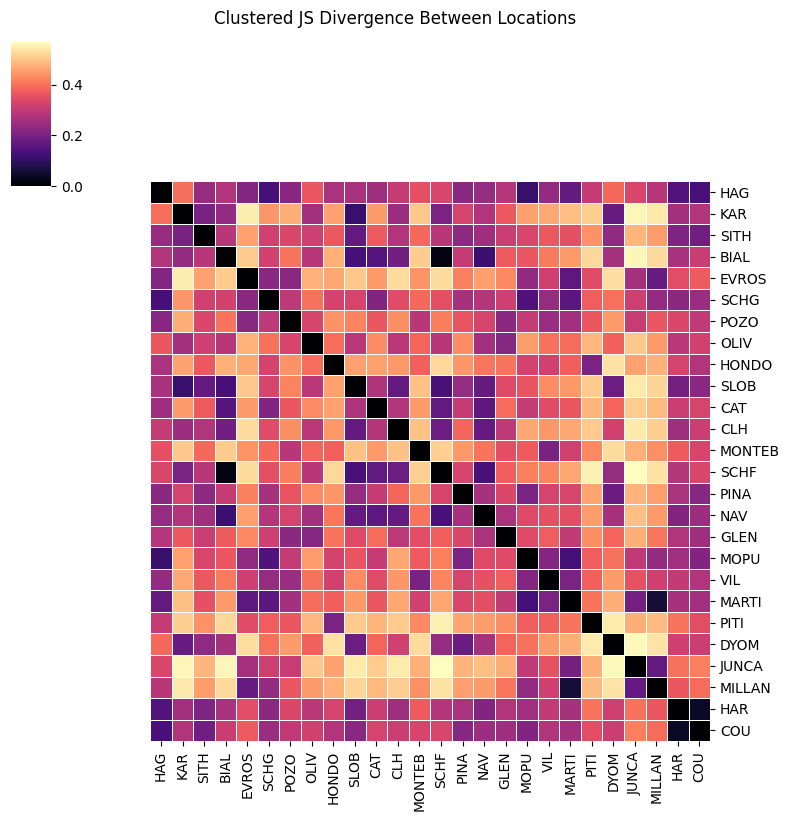

Weights (Predictive Distribution): [0.0215509  0.04379152 0.0316993  0.03488931 0.0471702  0.02721128
 0.03685728 0.04235694 0.0512751  0.03210865 0.03864607 0.04027763
 0.0537968  0.03785666 0.03469684 0.02767914 0.03731154 0.02990307
 0.03620553 0.03139887 0.0595947  0.04557492 0.05899663 0.04992153
 0.02455905 0.02467055]


In [17]:

similarity_matrix = correlation(sorted_indices, probabilities=y_pred_test)

alpha = 2
weights = similarity_matrix.sum(axis=1) ** alpha
weights = weights / weights.sum()

print(f"Weights (Predictive Distribution): {weights}")

## Label Distribution

JS-divergence between the true distribution of labels within strata.

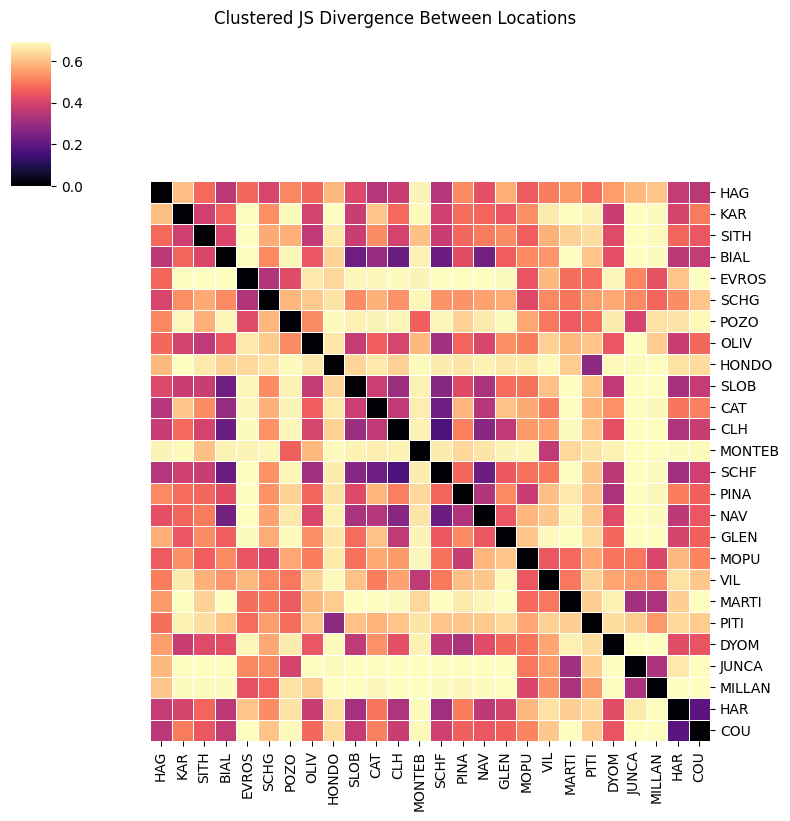

Weights (Label Distribution):
 [0.03006501 0.03843783 0.03466614 0.02910402 0.04695282 0.03735533
 0.04601039 0.03297914 0.0536626  0.02965589 0.03658905 0.02975528
 0.05425888 0.02702837 0.03655563 0.03154517 0.04084653 0.03442657
 0.04131584 0.04581399 0.0443122  0.03511783 0.04920502 0.04836173
 0.03131039 0.03466837]


In [18]:

similarity_matrix = correlation(sorted_indices, labels=tensor_y_test, mode="labels")

alpha = 2
weights = similarity_matrix.sum(axis=1) ** alpha
weights = weights / weights.sum()

print(f"Weights (Label Distribution):\n {weights}")